🚀 BẮT ĐẦU VERSION 2: THI ĐẤU THUẬT TOÁN (BASELINE) 🚀
>>> [Preprocess] Bắt đầu làm sạch dữ liệu...
>>> [Preprocess] Đang học bộ mã hóa từ tập Train...
>>> [Preprocess] Đang chuyển đổi dữ liệu Chữ thành Số...
>>> [Preprocess] Hoàn thành!
>>> [Feature Engineering] Bắt đầu tạo các biến số mới...
>>> [Feature Engineering] Hoàn thành! Dữ liệu hiện có 84 cột.
[V1: Ridge (Tuyến tính)] R2 Score: 0.8709 | MAE: 18224 USD
[V2: Decision Tree] R2 Score: 0.8677 | MAE: 18714 USD
[V2: Random Forest] R2 Score: 0.8861 | MAE: 17383 USD
[V2: Gradient Boost] R2 Score: 0.8996 | MAE: 16488 USD
[V2: XGBoost Base] R2 Score: 0.8924 | MAE: 15696 USD


C:\Users\haaaa\AppData\Local\Temp\ipykernel_2208\3727654352.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=model_names, y=scores, palette="magma")


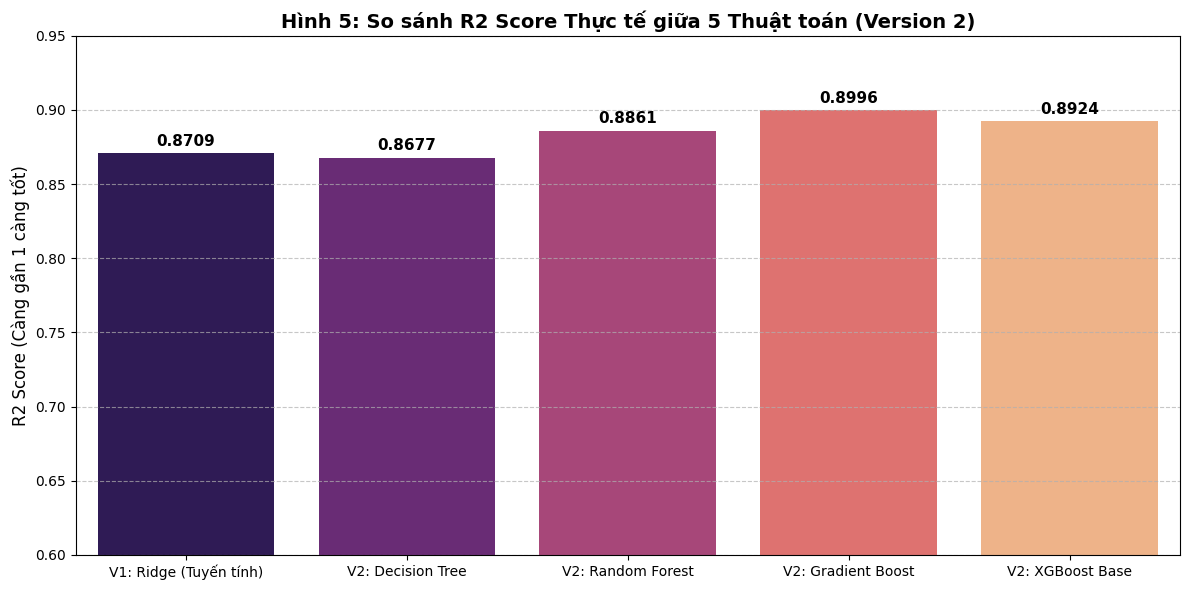

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), ".")))
from src.preprocess.preprocess import DataPreprocessor
from src.features.features import FeatureEngineer

print("=" * 50)
print("🚀 BẮT ĐẦU VERSION 2: THI ĐẤU THUẬT TOÁN (BASELINE) 🚀")
print("=" * 50)

# 1. NẠP VÀ LÀM SẠCH DỮ LIỆU
df_train = pd.read_csv("data/train.csv")
X_raw = df_train.drop(columns=["SalePrice", "Id"])

y = np.log1p(df_train["SalePrice"])

preprocessor = DataPreprocessor()
X_clean = preprocessor.process(X_raw, is_train=True)

fe = FeatureEngineer()
X = fe.create_features(X_clean)

# Chia Train/Test 80/20 truyền thống
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. KHAI BÁO CÁC MÔ HÌNH
models = {
    "V1: Ridge (Tuyến tính)": Ridge(alpha=10),
    "V2: Decision Tree": RandomForestRegressor(
        n_estimators=10, max_depth=10, random_state=42
    ),  # Thay bằng Tree đơn giản
    "V2: Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "V2: Gradient Boost": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "V2: XGBoost Base": XGBRegressor(
        n_estimators=100, learning_rate=0.1, random_state=42
    ),
}

# 3. HUẤN LUYỆN VÀ GHI NHẬN KẾT QUẢ THỰC TẾ
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    results[name] = r2

    mae_usd = mean_absolute_error(np.expm1(y_test), np.expm1(preds))

    print(f"[{name}] R2 Score: {r2:.4f} | MAE: {mae_usd:.0f} USD")

# 4. VẼ BIỂU ĐỒ TỪ KẾT QUẢ THỰC TẾ
plt.figure(figsize=(12, 6))
model_names = list(results.keys())
scores = list(results.values())

ax = sns.barplot(x=model_names, y=scores, palette="magma")
for i, v in enumerate(scores):
    ax.text(
        i,
        v + 0.005,
        f"{v:.4f}",
        color="black",
        ha="center",
        fontweight="bold",
        fontsize=11,
    )

plt.ylim(0.60, 0.95)
plt.title(
    "Hình 5: So sánh R2 Score Thực tế giữa 5 Thuật toán (Version 2)",
    fontsize=14,
    fontweight="bold",
)
plt.ylabel("R2 Score (Càng gần 1 càng tốt)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

os.makedirs("reports", exist_ok=True)
plt.savefig("reports/03_model_comparison_v2.png", dpi=300)
plt.show()